# Chapter 1 — The Machine Learning Landscape

## Table of Contents

1. [What Is Machine Learning?](#1)
2. [Why Use Machine Learning?](#2)
3. [Types of Machine Learning Systems](#3)
    - 3.1 Training Supervision
    - 3.2 Batch vs Online Learning
    - 3.3 Instance-Based vs Model-Based Learning
4. [Supervised Learning Examples (Code)](#4)
5. [Unsupervised Learning Examples (Code)](#5)
6. [Main Challenges of Machine Learning](#6)
7. [Testing and Validating](#7)
8. [No Free Lunch Theorem](#8)

<a id='1'></a>
## 1) What Is Machine Learning?

> *"A computer program is said to learn from experience **E** with respect to some task **T** and some performance measure **P**, if its performance on T, as measured by P, improves with experience E."*  
> — **Tom Mitchell, 1997**

<a id='2'></a>
## 2) Why Use Machine Learning?

1. **Problems requiring many hand-tuned rules** — ML can simplify code and perform better
2. **Complex problems with no good traditional solution** — e.g., speech recognition across thousands of words, millions of speakers, noisy environments
3. **Fluctuating environments** — ML systems can be retrained on new data to stay up to date
4. **Getting insights about complex problems** — ML excels at **data mining** (discovering hidden patterns in large datasets)

<a id='3'></a>
## 3) Types of Machine Learning Systems

ML systems can be classified along **three orthogonal axes** (not mutually exclusive):

1. **Training supervision** — how are they guided during training?
2. **Learning mode** — can they learn incrementally? (online vs batch)
3. **Generalization approach** — instance-based vs model-based?

---

### 3.1 Training Supervision

#### Supervised Learning
- Training data includes **labels** (desired solutions)
- Two main tasks:
  - **Classification:** predict a discrete class (e.g., spam vs ham)
  - **Regression:** predict a continuous target value (e.g., car price)
- Some models can do both (e.g., Logistic Regression outputs class probabilities)

#### Unsupervised Learning
- Training data is **unlabeled**
- **Clustering** — detect groups of similar instances (e.g., KMeans, DBSCAN)
- **Visualization** — project complex data to 2D/3D while preserving structure
- **Dimensionality reduction** — merge correlated features into fewer ones (feature extraction)
- **Anomaly detection** — flag unusual instances (e.g., fraud); trained mostly on normal data
- **Novelty detection** — like anomaly detection but requires a perfectly clean training set
- **Association rule learning** — discover relations between attributes (e.g., market basket analysis)

#### Semi-supervised Learning
- **Partially labeled data** — plenty of unlabeled instances, few labeled ones
- Example: Google Photos clusters faces (unsupervised), then asks you to label each person once
- Most semi-supervised algorithms combine unsupervised + supervised techniques

#### Self-supervised Learning
- Generates a **fully labeled dataset from unlabeled data**
- Example: mask part of an image → train model to recover original
- Key concept: **Transfer learning** — pretrained model fine-tuned for the actual task
- LLMs work this way: mask words → predict missing → fine-tune for downstream tasks

#### Reinforcement Learning (RL)
- An **agent** observes the environment, performs actions, gets **rewards** (or penalties)
- Learns the best **policy** (what action to choose in each situation) to maximize reward over time
- Examples: robots learning to walk, AlphaGo

---

### 3.2 Batch vs Online Learning

#### Batch Learning (Offline Learning)
- Trained on **all available data at once** → typically done offline
- After training, deployed and runs without further learning
- **Data drift** (model rot): performance decays as the world evolves while the model stays static
- Solution: regularly retrain on updated data
- **Drawbacks:** expensive in compute; slow to adapt; can't handle resource-constrained scenarios

#### Online Learning (Incremental Learning)
- Trained **incrementally** — data fed sequentially (individually or in **mini-batches**)
- Each learning step is fast and cheap
- Key parameter: **learning rate**
  - High rate → adapts fast but forgets old data (**catastrophic forgetting**)
  - Low rate → more inertia, less sensitive to noise
- **Out-of-core learning:** uses online algorithms to train on datasets too large for memory
- **Risk:** bad data can quickly degrade performance → need monitoring and anomaly detection

> ⚠️ **Terminology confusion (from book):**  
> - "Online learning" is often done offline → think of it as **incremental learning**  
> - "Batch learning" mini-batches ≠ batch learning → think of it as **learning from scratch on full dataset**

---

### 3.3 Instance-Based vs Model-Based Learning

#### Instance-Based Learning
- Learns examples **by heart**, generalizes using a **similarity measure**
- Example: k-Nearest Neighbors (k-NN)
- Pros: works well with small, changing datasets
- Cons: doesn't scale well; requires full training set in production; slow predictions; poor with high-dimensional data

#### Model-Based Learning
- Builds a **model** from examples, uses it for predictions
- Workflow:
  1. **Study the data**
  2. **Select a model** (model selection)
  3. **Train it** (learning algorithm finds parameters minimizing a cost function)
  4. **Apply the model** to make predictions (**inference**)
- Key concepts:
  - **Model parameters** (e.g., θ₀, θ₁ in linear regression)
  - **Utility/fitness function** — measures how good the model is
  - **Cost/loss function** — measures how bad the model is
  - **Training** — finding optimal parameter values

> ⚠️ **"Model" ambiguity (from book):** can mean a *type of model* (e.g., linear regression), a *fully specified architecture* (linear regression with one input/output), or the *final trained model* (with specific parameter values)

<a id='4'></a>
## 4) Supervised Learning — Code Examples

### 4.1 Regression Example (Linear Regression)
We demonstrate a simple linear regression using synthetic data, train/test split, and evaluate with MSE and R².

## Code walkthrough: linear regression

This cell builds a simple supervised learning example. It creates synthetic numeric data, splits it into train/test sets, fits a linear regression model, and then evaluates the predictions with mean squared error and $R^2$. The printed model parameters show the learned intercept and slope, which is useful for understanding how the model maps the input feature to the target value.

MSE: 173.59, R2: 0.98
Model parameters: θ₀ (intercept) = 1.3862, θ₁ (slope) = 86.2556


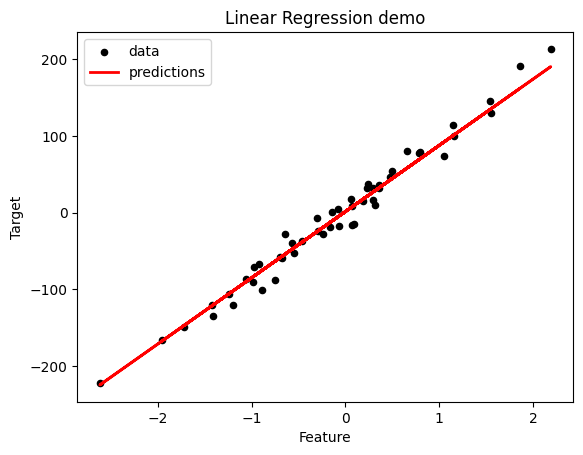

In [3]:
# Linear regression example
import numpy as np
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# synthetic data
X, y = make_regression(n_samples=200, n_features=1, noise=12.0, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse:.2f}, R2: {r2:.2f}')
print(f'Model parameters: θ₀ (intercept) = {model.intercept_:.4f}, θ₁ (slope) = {model.coef_[0]:.4f}')

# plot
plt.scatter(X_test, y_test, color='black', s=20, label='data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='predictions')
plt.legend()
plt.title('Linear Regression demo')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.show()

### 5.2 Classification Example (Logistic Regression)

As noted in the book: *"Logistic regression is commonly used for classification, as it can output a value that corresponds to the probability of belonging to a given class."*

We build a synthetic binary classification dataset and evaluate with accuracy, precision, recall, F1, and confusion matrix.

### Code walkthrough: logistic regression

This cell turns a synthetic classification problem into a supervised learning example. The logistic regression model is trained on two features, then used to predict the class labels for the test set. Accuracy gives a quick summary, the classification report breaks down precision and recall, and the confusion matrix visualizes where the model gets predictions right or wrong.

Accuracy: 0.9222222222222223
Classification report:               precision    recall  f1-score   support

           0       0.93      0.91      0.92        47
           1       0.91      0.93      0.92        43

    accuracy                           0.92        90
   macro avg       0.92      0.92      0.92        90
weighted avg       0.92      0.92      0.92        90



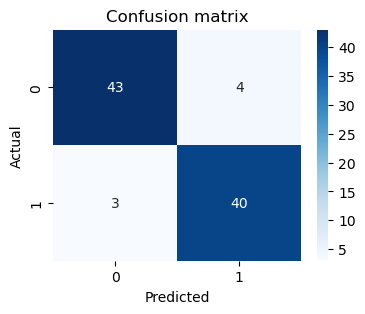

In [4]:
# Logistic regression example
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

Xc, yc = make_classification(n_samples=300, n_features=2, n_redundant=0, n_clusters_per_class=1, random_state=2)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.3, random_state=42)
clf = LogisticRegression(solver='liblinear')
clf.fit(Xc_train, yc_train)
yp = clf.predict(Xc_test)
print('Accuracy:', accuracy_score(yc_test, yp))
print('Classification report:', classification_report(yc_test, yp))
cm = confusion_matrix(yc_test, yp)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

<a id='5'></a>
## 5) Unsupervised Learning — Code Examples

### 5.1 Clustering (KMeans)
### 5.2 Dimensionality Reduction (PCA)

## Code walkthrough: KMeans and PCA

This cell shows two unsupervised learning ideas. KMeans clusters unlabeled points into groups and learns cluster centers. PCA then projects the same data into a lower-dimensional space so the structure is easier to inspect. Together they show how unsupervised methods can reveal patterns without target labels.

c:\Users\Victus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


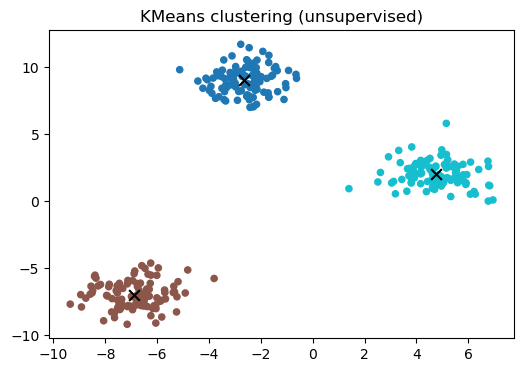

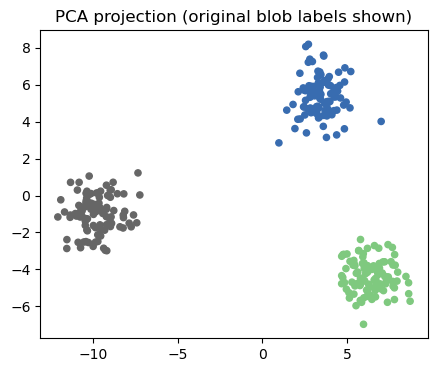

In [5]:
# KMeans and PCA demo
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

Xb, yb = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(Xb)

plt.figure(figsize=(6,4))
plt.scatter(Xb[:,0], Xb[:,1], c=labels, cmap='tab10', s=20)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c='black', s=60, marker='x')
plt.title('KMeans clustering (unsupervised)')
plt.show()

# PCA example (project to 2D if higher dimensional data)
pca = PCA(n_components=2)
Xp = pca.fit_transform(Xb)
plt.figure(figsize=(5,4))
plt.scatter(Xp[:,0], Xp[:,1], c=yb, cmap='Accent', s=20)
plt.title('PCA projection (original blob labels shown)')
plt.show()

### Bonus: Model-Based Learning — GDP vs Life Satisfaction (from the book)

The book's central example in this chapter: using GDP per capita to predict life satisfaction with a linear model.

Linear Regression prediction for Puerto Rico: 6.05
k-NN (k=3) prediction for Puerto Rico: 5.87

Model parameters: θ₀ = 4.11, θ₁ = 5.82e-05


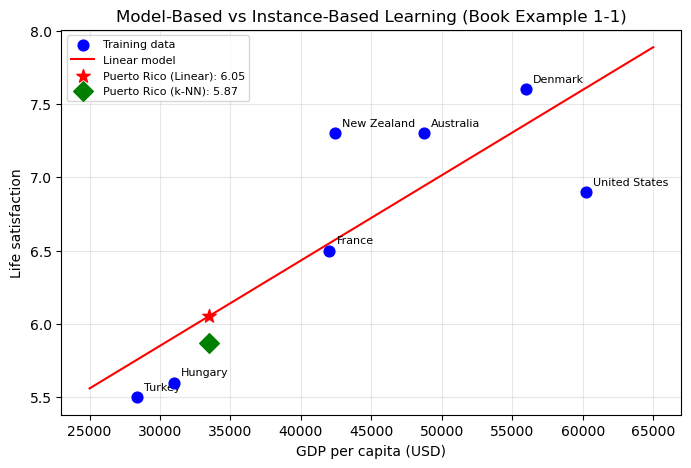

In [6]:
# Recreating the book's GDP vs Life Satisfaction example
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

# Data from Table 1-1 in the book
countries = ['Turkey', 'Hungary', 'France', 'United States', 'New Zealand', 'Australia', 'Denmark']
gdp_per_capita = np.array([28384, 31008, 42026, 60236, 42404, 48698, 55938]).reshape(-1, 1)
life_satisfaction = np.array([5.5, 5.6, 6.5, 6.9, 7.3, 7.3, 7.6])

# Model-based: Linear Regression
lin_model = LinearRegression()
lin_model.fit(gdp_per_capita, life_satisfaction)

# Instance-based: k-Nearest Neighbors
knn_model = KNeighborsRegressor(n_neighbors=3)
knn_model.fit(gdp_per_capita, life_satisfaction)

# Predict for Puerto Rico (GDP per capita = $33,442)
puerto_rico_gdp = np.array([[33442.8]])
lin_pred = lin_model.predict(puerto_rico_gdp)[0]
knn_pred = knn_model.predict(puerto_rico_gdp)[0]

print(f'Linear Regression prediction for Puerto Rico: {lin_pred:.2f}')
print(f'k-NN (k=3) prediction for Puerto Rico: {knn_pred:.2f}')
print(f'\nModel parameters: θ₀ = {lin_model.intercept_:.2f}, θ₁ = {lin_model.coef_[0]:.2e}')

# Plot
X_range = np.linspace(25000, 65000, 100).reshape(-1, 1)
plt.figure(figsize=(8, 5))
plt.scatter(gdp_per_capita, life_satisfaction, c='blue', s=60, zorder=5, label='Training data')
plt.plot(X_range, lin_model.predict(X_range), 'r-', label='Linear model')
plt.scatter(puerto_rico_gdp, lin_pred, c='red', s=100, marker='*', zorder=5, label=f'Puerto Rico (Linear): {lin_pred:.2f}')
plt.scatter(puerto_rico_gdp, knn_pred, c='green', s=100, marker='D', zorder=5, label=f'Puerto Rico (k-NN): {knn_pred:.2f}')
for i, country in enumerate(countries):
    plt.annotate(country, (gdp_per_capita[i][0], life_satisfaction[i]), 
                 textcoords='offset points', xytext=(5, 5), fontsize=8)
plt.xlabel('GDP per capita (USD)')
plt.ylabel('Life satisfaction')
plt.title('Model-Based vs Instance-Based Learning (Book Example 1-1)')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.show()

<a id='6'></a>
## 6) Main Challenges of Machine Learning

Two things can go wrong: **"bad model"** and **"bad data"**.

---

### 6.1 Bad Data

#### Insufficient Quantity of Training Data
- Most ML algorithms need **thousands of examples** (millions for complex problems like image/speech recognition)
- **"The Unreasonable Effectiveness of Data"** (Banko & Brill, 2001; Norvig et al., 2009): different algorithms perform similarly once given enough data
- However, small/medium datasets are still common, and extra data is not always easy to get

#### Nonrepresentative Training Data
- Training data must be **representative** of what you'll encounter in production
- **Sampling noise:** nonrepresentative data due to chance (small samples)
- **Sampling bias:** nonrepresentative data due to flawed sampling method
  - Famous example: *Literary Digest* 1936 election poll — sent to 10 million people (from phone directories, magazine subscribers = wealthier people) → predicted wrong winner

#### Poor-Quality Data
- Errors, outliers, and noise make it harder to detect underlying patterns
- **Solutions:** discard/fix outliers; handle missing features (ignore, fill with median, or train separate models)

#### Irrelevant Features
- "Garbage in, garbage out"
- **Feature engineering** is critical:
  - **Feature selection** — choosing the most useful existing features
  - **Feature extraction** — combining features (dimensionality reduction helps)
  - **Creating new features** by gathering new data

---

### 6.2 Bad Algorithms

#### Overfitting the Training Data
- Model performs well on training data but **does not generalize** well
- Happens when the model is **too complex** relative to the amount/noisiness of data
- The model detects patterns in the **noise** itself
- **Solutions:**
  1. **Simplify the model** (fewer parameters, fewer features)
  2. **Gather more training data**
  3. **Reduce noise** (fix errors, remove outliers)
- **Regularization:** constraining a model to reduce overfitting
  - Controlled by a **hyperparameter** (set before training, not learned)
  - Too much regularization → almost flat model → underfitting

#### Underfitting the Training Data
- Model is **too simple** to capture the data's structure
- **Solutions:**
  1. Select a **more powerful model** (more parameters)
  2. **Better features** (feature engineering)
  3. **Reduce regularization** constraints

### Overfitting vs Underfitting — Visual Demo

### Code walkthrough: references and next steps

This closing section points you to the original chapter and the libraries used in the examples. If you want to continue, the next natural step is to revisit the code cells, rerun them, and modify the synthetic datasets to see how the metrics and plots change.

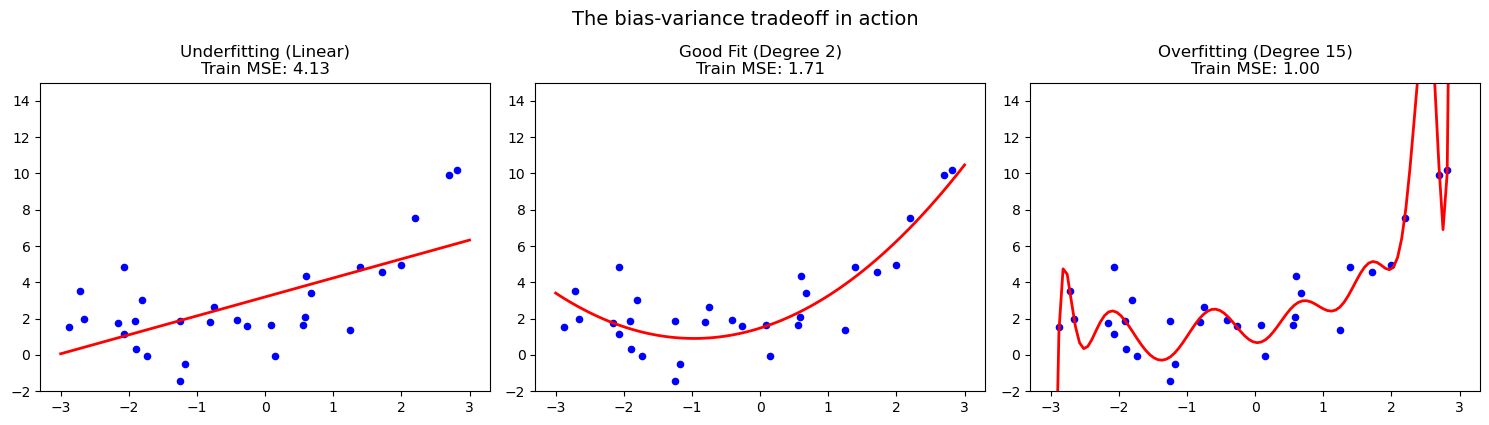

In [7]:
# Overfitting vs Underfitting demo
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Generate noisy data from a quadratic function
np.random.seed(42)
X = np.sort(np.random.rand(30, 1) * 6 - 3, axis=0)
y = 0.5 * X.ravel()**2 + X.ravel() + 2 + np.random.randn(30) * 1.5

X_plot = np.linspace(-3, 3, 100).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Underfitting: too simple (linear)
model_under = LinearRegression()
model_under.fit(X, y)
axes[0].scatter(X, y, s=20, c='blue')
axes[0].plot(X_plot, model_under.predict(X_plot), 'r-', linewidth=2)
axes[0].set_title(f'Underfitting (Linear)\nTrain MSE: {mean_squared_error(y, model_under.predict(X)):.2f}')
axes[0].set_ylim(-2, 15)

# Good fit: polynomial degree 2
model_good = make_pipeline(PolynomialFeatures(2), LinearRegression())
model_good.fit(X, y)
axes[1].scatter(X, y, s=20, c='blue')
axes[1].plot(X_plot, model_good.predict(X_plot), 'r-', linewidth=2)
axes[1].set_title(f'Good Fit (Degree 2)\nTrain MSE: {mean_squared_error(y, model_good.predict(X)):.2f}')
axes[1].set_ylim(-2, 15)

# Overfitting: polynomial degree 15
model_over = make_pipeline(PolynomialFeatures(15), LinearRegression())
model_over.fit(X, y)
axes[2].scatter(X, y, s=20, c='blue')
y_over = model_over.predict(X_plot)
y_over = np.clip(y_over, -10, 30)  # clip for visualization
axes[2].plot(X_plot, y_over, 'r-', linewidth=2)
axes[2].set_title(f'Overfitting (Degree 15)\nTrain MSE: {mean_squared_error(y, model_over.predict(X)):.2f}')
axes[2].set_ylim(-2, 15)

plt.tight_layout()
plt.suptitle('The bias-variance tradeoff in action', y=1.05, fontsize=14)
plt.show()

### Regularization Demo

The book explains: *"Constraining a model to make it simpler and reduce the risk of overfitting is called regularization."*

Here we show how Ridge regression (L2 regularization) controls the degree of freedom.

### Code walkthrough: evaluation metrics

This section summarizes the metrics you should remember from Chapter 1 and later chapters. For regression, the main ideas are error size and explained variance. For classification, the focus is on accuracy, precision, recall, F1 score, ROC-AUC, and confusion matrices. These metrics help compare models more carefully than raw predictions alone.

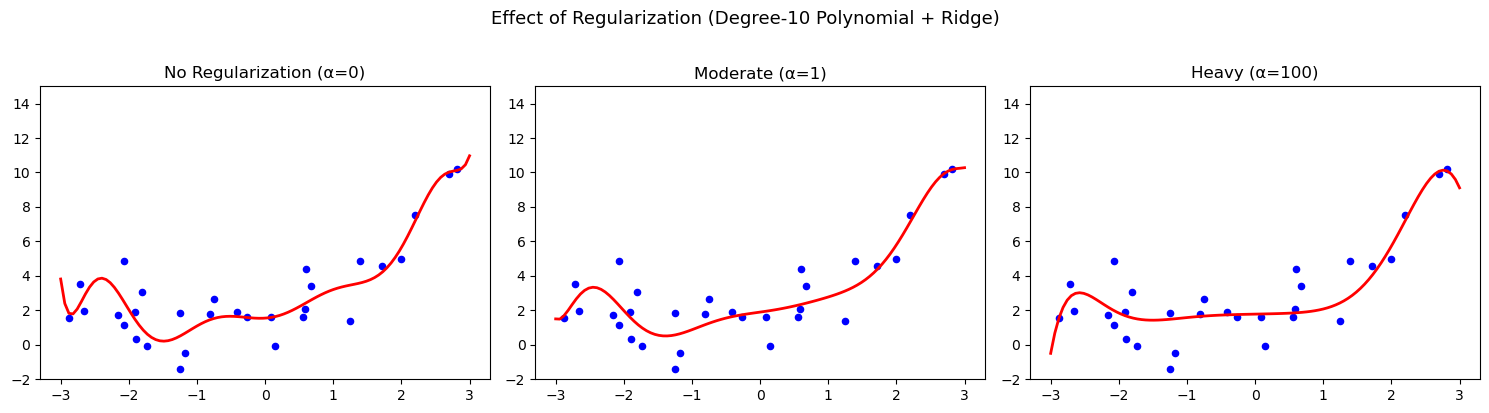

In [8]:
# Regularization demo: Ridge regression with different alpha values
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
alphas = [0, 1, 100]  # no regularization, moderate, heavy
titles = ['No Regularization (α=0)', 'Moderate (α=1)', 'Heavy (α=100)']

for ax, alpha, title in zip(axes, alphas, titles):
    model = make_pipeline(PolynomialFeatures(10), Ridge(alpha=alpha))
    model.fit(X, y)
    ax.scatter(X, y, s=20, c='blue')
    y_plot = model.predict(X_plot)
    y_plot = np.clip(y_plot, -5, 20)
    ax.plot(X_plot, y_plot, 'r-', linewidth=2)
    ax.set_title(title)
    ax.set_ylim(-2, 15)

plt.suptitle('Effect of Regularization (Degree-10 Polynomial + Ridge)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

<a id='7'></a>
## 7) Testing and Validating

### 7.1 Train/Test Split
- Split data into a **training set** (typically 80%) and a **test set** (20%)
- The error rate on new cases is called the **generalization error** (or **out-of-sample error**)
- If training error is low but generalization error is high → **overfitting**

> *Tip (from book): If dataset has 10 million instances, holding out just 1% still gives 100,000 test instances — likely enough for a good estimate.*

### 7.2 Hyperparameter Tuning & Model Selection
- **Problem:** If you tune hyperparameters on the test set, you overfit *to that test set*
- **Solution: Holdout Validation**
  1. Hold out a **validation set** (dev set) from the training set
  2. Train models with various hyperparameters on the reduced training set
  3. Select the model that performs best on the validation set
  4. Retrain the best model on the **full training set** (including validation set)
  5. Evaluate the final model on the **test set** for a generalization error estimate

### 7.3 Cross-Validation
- If validation set is too small → imprecise evaluation; too large → training set too small
- **k-fold Cross-Validation:** use many small validation sets, train on the rest each time, average all evaluations
- **Drawback:** training time multiplied by number of folds

### 7.4 Data Mismatch
- Sometimes abundant training data isn't representative of production data
- **Example:** training on web flower images but deploying on mobile phone photos
- **Key rule:** Validation and test sets must be representative of **production data**
- **Train-dev set** (coined by Andrew Ng):
  - Hold out some training data → if model performs poorly on train-dev set = **overfitting**
  - If good on train-dev but poor on validation = **data mismatch**

### Cross-Validation Demo

### Code walkthrough: practical tips

This short section explains the habits that matter in real machine learning work: inspect your data, scale features when needed, avoid leakage, use train/test splits or cross-validation, and prefer simple baselines before tuning complex models. These ideas keep experiments reliable and make the rest of the notebook easier to interpret.

In [9]:
# Cross-validation demo
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_regression
import numpy as np

# Generate data
X_cv, y_cv = make_regression(n_samples=100, n_features=1, noise=15.0, random_state=42)

models = {
    'Linear': LinearRegression(),
    'Poly (deg=2)': make_pipeline(PolynomialFeatures(2), LinearRegression()),
    'Poly (deg=10)': make_pipeline(PolynomialFeatures(10), LinearRegression()),
    'Poly (deg=10) + Ridge': make_pipeline(PolynomialFeatures(10), Ridge(alpha=1.0)),
}

print(f'{"Model":<25} {"Mean R² (5-fold CV)":<20} {"Std":<10}')
print('-' * 55)
for name, model in models.items():
    scores = cross_val_score(model, X_cv, y_cv, cv=5, scoring='r2')
    print(f'{name:<25} {scores.mean():<20.4f} {scores.std():<10.4f}')

Model                     Mean R² (5-fold CV)  Std       
-------------------------------------------------------
Linear                    0.8945               0.0451    
Poly (deg=2)              0.8942               0.0449    
Poly (deg=10)             -2.2824              5.6328    
Poly (deg=10) + Ridge     -0.6857              2.5008    


<a id='8'></a>
## 8) No Free Lunch Theorem

> *In a famous 1996 paper, David Wolpert demonstrated that if you make absolutely no assumption about the data, then there is no reason to prefer one model over any other. This is called the **No Free Lunch (NFL) theorem**.*

### Key Takeaways
- **No model is *a priori* guaranteed to work best** for all datasets
- For some datasets, linear models are best; for others, neural networks win
- In practice, you **make reasonable assumptions** about the data and **evaluate a few reasonable models**
- A model is a **simplified representation** of data — simplifications discard details unlikely to generalize
- When you choose a model type, you're **implicitly making assumptions** about the data
  - e.g., choosing linear regression assumes the data is fundamentally linear

> *Reference: David Wolpert, "The Lack of A Priori Distinctions Between Learning Algorithms", Neural Computation 8, no. 7 (1996): 1341–1390.*